## Churn prediction

In [14]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
    confusion_matrix, roc_auc_score, roc_curve)
import xgboost as xgb
import warnings; warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

df = pd.read_csv('../data/raw/telco_churn.csv')

print(f"Shape: {df.shape}")
print(f"Churn distribution:")
print(df['Churn'].value_counts())
print(f"Churn rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/telco_churn.csv'

In [1]:
import os

# Where is your notebook running from?
print("Notebook is running from:")
print(os.getcwd())

# What's in your project folder?
print("\nFiles and folders here:")
for item in os.listdir('.'):
    print(f"  {item}")

Notebook is running from:
C:\Users\Admin\Downloads\New folder\New folder\notebooks

Files and folders here:
  .ipynb_checkpoints
  01_EDA.ipynb .ipynb
  02_RFM.ipynb
  03_Clustering.ipynb
  04_Churn_Prediction.ipynb


In [3]:
import os

# Check if data/raw folder exists
path = r"C:\Users\Admin\Downloads\New folder\New folder\data\raw"

print(f"Does data/raw exist? {os.path.exists(path)}")

# Show what's inside data folder
data_path = r"C:\Users\Admin\Downloads\New folder\New folder\data"
if os.path.exists(data_path):
    print(f"\nContents of data/ folder:")
    for item in os.listdir(data_path):
        print(f"  {item}")
else:
    print("\ndata/ folder does NOT exist!")

Does data/raw exist? True

Contents of data/ folder:
  processed
  raw


In [6]:
import os

# Create the folders if they don't exist
os.makedirs(r"C:\Users\Admin\Downloads\New folder\New folder\data\raw", exist_ok=True)
os.makedirs(r"C:\Users\Admin\Downloads\New folder\New folder\data\processed", exist_ok=True)

print("Folders created ✅")

# Now download the dataset directly into it
import urllib.request

url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/Telco-Customer-Churn.csv"
save_path = r"C:\Users\Admin\Downloads\New folder\New folder\data\raw\telco_churn.csv"

urllib.request.urlretrieve(url, save_path)
print("File downloaded ✅")

# Verify
import pandas as pd
df = pd.read_csv(save_path)
print(f"\nShape: {df.shape}")
print(df['Churn'].value_counts())

Folders created ✅


HTTPError: HTTP Error 404: Not Found

In [8]:
import urllib.request
import os

os.makedirs(r"C:\Users\Admin\Downloads\New folder\New folder\data\raw", exist_ok=True)

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
save_path = r"C:\Users\Admin\Downloads\New folder\New folder\data\raw\telco_churn.csv"

urllib.request.urlretrieve(url, save_path)
print("Downloaded ✅")

import pandas as pd
df = pd.read_csv(save_path)
print(f"Shape: {df.shape}")
print(df['Churn'].value_counts())

Downloaded ✅
Shape: (7043, 21)
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [9]:
import pandas as pd
df = pd.read_csv('../data/raw/telco_churn.csv')
print(f"Shape: {df.shape}")
print(df['Churn'].value_counts())

Shape: (7043, 21)
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [11]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
    confusion_matrix, roc_auc_score, roc_curve)
import xgboost as xgb
import warnings; warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

df = pd.read_csv('../data/raw/telco_churn.csv')

print(f"Shape: {df.shape}")
print(f"Churn distribution:")
print(df['Churn'].value_counts())
print(f"Churn rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")

Shape: (7043, 21)
Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn rate: 26.5%


In [13]:
print(df.dtypes)
print(f"Missing values:")
print(df.isnull().sum()[df.isnull().sum()>0])

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
Missing values:
Series([], dtype: int64)


Data cleaning & encoding

In [14]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

df.drop('customerID', axis=1, inplace=True)

print(f"TotalCharges fixed ✅")
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")

TotalCharges fixed ✅
Shape: (7043, 20)
Missing values: 0


In [16]:
df_encoded = df.copy()

le = LabelEncoder()
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("All columns encoded ✅")
print(df_encoded.dtypes)
print(f"Churn distribution after encoding:")
print(df_encoded['Churn'].value_counts())

All columns encoded ✅
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object
Churn distribution after encoding:
Churn
0    5174
1    1869
Name: count, dtype: int64


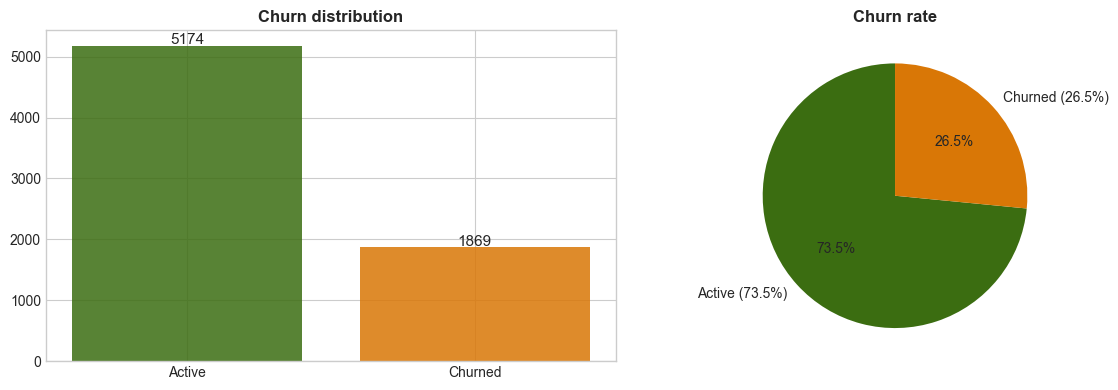

Saved ✅


In [17]:
fig, axes = plt.subplots(1,2,figsize=(12,4))

counts = df['Churn'].value_counts()
axes[0].bar(['Active','Churned'], counts.values,
            color=['#3b6d11','#d97706'], alpha=0.85)
axes[0].set_title('Churn distribution', fontweight='bold')
for i,(l,v) in enumerate(zip(['Active','Churned'],counts.values)):
    axes[0].text(i, v+30, f'{v}', ha='center', fontsize=11)

axes[1].pie(counts.values,
            labels=['Active (73.5%)','Churned (26.5%)'],
            colors=['#3b6d11','#d97706'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Churn rate', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/churn_distribution.png', dpi=150)
plt.show()
print("Saved ✅")

Train/test split & scaling

In [18]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set:  {X_train.shape[0]:,} rows")
print(f"Test set:      {X_test.shape[0]:,} rows")
print(f"Features:      {X_train.shape[1]}")
print(f"Churn in train: {y_train.mean()*100:.1f}%")
print(f"Churn in test:  {y_test.mean()*100:.1f}%")

Training set:  5,634 rows
Test set:      1,409 rows
Features:      19
Churn in train: 26.5%
Churn in test:  26.5%


In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Features scaled ✅")
print("Logistic Regression uses scaled, tree models use unscaled")

Features scaled ✅
Logistic Regression uses scaled, tree models use unscaled


In [20]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:,1]

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds,
      target_names=['Active','Churned']))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

      Active       0.84      0.89      0.87      1035
     Churned       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.8403


In [21]:
rf = RandomForestClassifier(n_estimators=100,
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:,1]

print("=== Random Forest ===")
print(classification_report(y_test, rf_preds,
      target_names=['Active','Churned']))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

      Active       0.83      0.90      0.86      1035
     Churned       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.8225


In [22]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:,1]

print("=== XGBoost ===")
print(classification_report(y_test, xgb_preds,
      target_names=['Active','Churned']))
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_proba):.4f}")

=== XGBoost ===
              precision    recall  f1-score   support

      Active       0.84      0.90      0.87      1035
     Churned       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.8392


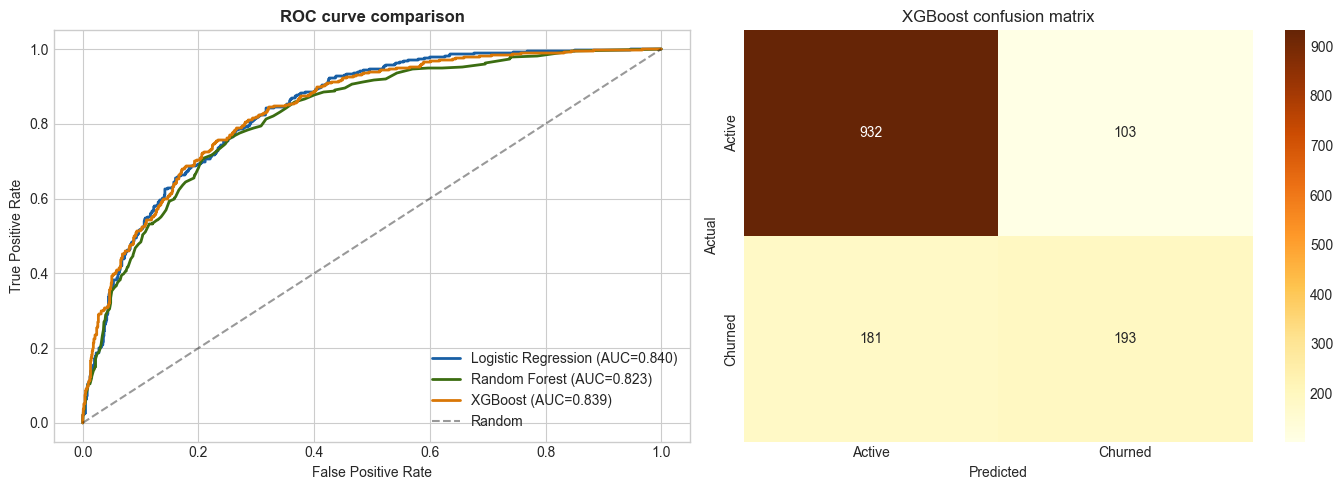

Saved ✅


In [23]:
fig, axes = plt.subplots(1,2,figsize=(14,5))

models_eval = {
    'Logistic Regression': (lr_proba,  '#185fa5'),
    'Random Forest':       (rf_proba,  '#3b6d11'),
    'XGBoost':             (xgb_proba, '#d97706')
}
for name,(proba,color) in models_eval.items():
    fpr,tpr,_ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, linewidth=2,
                 label=f'{name} (AUC={auc:.3f})')
axes[0].plot([0,1],[0,1],'k--',alpha=0.4,label='Random')
axes[0].set_title('ROC curve comparison', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

cm = confusion_matrix(y_test, xgb_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=['Active','Churned'],
            yticklabels=['Active','Churned'], ax=axes[1])
axes[1].set_title('XGBoost confusion matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../reports/figures/roc_curves.png', dpi=150)
plt.show()
print("Saved ✅")

In [25]:
from sklearn.metrics import (f1_score, precision_score,
                              recall_score, accuracy_score)

results = pd.DataFrame({
    'Model': ['Logistic Regression','Random Forest','XGBoost'],
    'Accuracy':  [accuracy_score(y_test,lr_preds),
                  accuracy_score(y_test,rf_preds),
                  accuracy_score(y_test,xgb_preds)],
    'Precision': [precision_score(y_test,lr_preds),
                  precision_score(y_test,rf_preds),
                  precision_score(y_test,xgb_preds)],
    'Recall':    [recall_score(y_test,lr_preds),
                  recall_score(y_test,rf_preds),
                  recall_score(y_test,xgb_preds)],
    'F1':        [f1_score(y_test,lr_preds),
                  f1_score(y_test,rf_preds),
                  f1_score(y_test,xgb_preds)],
    'ROC-AUC':   [roc_auc_score(y_test,lr_proba),
                  roc_auc_score(y_test,rf_proba),
                  roc_auc_score(y_test,xgb_proba)]
}).round(4)

results = results.sort_values('ROC-AUC', ascending=False)
print(results.to_string(index=False))
results.to_csv('../data/processed/model_comparison.csv', index=False)
print("Saved ✅")

              Model  Accuracy  Precision  Recall     F1  ROC-AUC
Logistic Regression    0.7991     0.6426  0.5481 0.5916   0.8403
            XGBoost    0.7984     0.6520  0.5160 0.5761   0.8392
      Random Forest    0.7921     0.6373  0.5027 0.5620   0.8225
Saved ✅


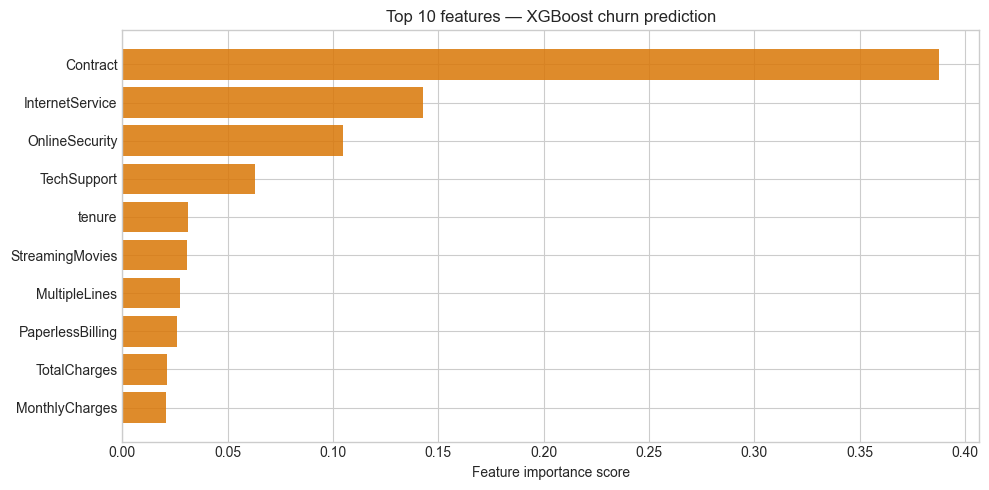

Top 10 churn drivers:
  Contract                    : 0.3874
  InternetService             : 0.1429
  OnlineSecurity              : 0.1048
  TechSupport                 : 0.0630
  tenure                      : 0.0313
  StreamingMovies             : 0.0306
  MultipleLines               : 0.0275
  PaperlessBilling            : 0.0260
  TotalCharges                : 0.0213
  MonthlyCharges              : 0.0209
Saved ✅


In [27]:
feat_importance = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10,5))
ax.barh(feat_importance['Feature'][::-1],
        feat_importance['Importance'][::-1],
        color='#d97706', alpha=0.85)
ax.set_title('Top 10 features — XGBoost churn prediction')
ax.set_xlabel('Feature importance score')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=150)
plt.show()

print("Top 10 churn drivers:")
for _,row in feat_importance.iterrows():
    print(f"  {row['Feature']:28s}: {row['Importance']:.4f}")
print("Saved ✅")

### Tenure, charges, and contract type are the top churn drivers. Short-tenure customers on month-to-month contracts paying high monthly fees are the highest risk. 